# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [7]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import main
import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [8]:
# Set the run directory.
model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D/wandb/run-20250729_104205-ktekeedj/files"

In [9]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(False)

In [10]:
# Feel free to change these arguments or add additional arguments here.

args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(200)
args["max_cycles"] = args["episode_length"]
args["seed"] = wrap_arg_val(1)

args["observation_probability"] = wrap_arg_val(0.5)
args["diffusion_autoregression_steps"] = wrap_arg_val(4)

In [11]:
# Convert arguments to the appropriate format.
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        v = value["value"]
        if v == None:
            continue
        if type(v) == bool:
            if v:
                arglist.append(f"--{key}")
            else:
                arglist.append(f"--no-{key}")
        else:
            arglist.append(f"--{key}")
            arglist.append(str(v))

## Perform Rendering

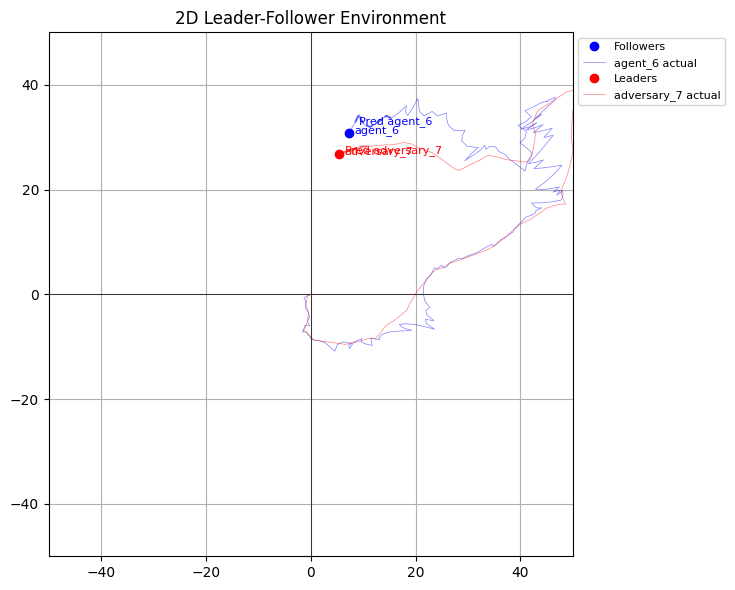

Step 199 - FPS: 11.59, Time per step: 0.0862s (excluding render)
Visibility Mask:
Agent 0: [[0. 0. 0. 0. 1. 1. 1. 1. 1.]]
Step 0 - FPS: 11.51, Time per step: 0.0869s (excluding render)


In [12]:
main(arglist)